In [2]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("E:\daihoc\daihoc1\computervision\lab\datatest/test.jpg") #path tới ảnh trong datatest 
if image is None:
    print("No image")
    exit()
 
cv2.imshow("Image", image)
_ = cv2.waitKey(0)

## Hồ Quốc Toản _ 052206014317
**I,Toán tử điểm ảnh** 
1. Thay đổi độ sáng: Tăng hoặc giảm độ sáng của toàn bộ hình ảnh bằng cách cộng hoặc trừ một giá trị cố định cho mỗi điểm ảnh.
2. Thay đổi độ tương phản: Tăng hoặc giảm độ tương phản bằng cách nhân mỗi điểm ảnh với một hằng số.


In [ ]:
#Thay đổi độ sáng: Tăng hoặc giảm độ sáng của toàn bộ hình ảnh bằng cách cộng hoặc trừ một giá trị cố định cho mỗi điểm ảnh.
value = 60
brightened = cv2.convertScaleAbs(image, alpha=1.0, beta=value)   # Tăng độ sáng
darkened = cv2.convertScaleAbs(image, alpha=1.0, beta=-value)     # Giảm độ sáng

cv2.imshow("Tang do sang (+60)", brightened)
cv2.imshow("Giam do sang (-60)", darkened)

cv2.waitKey(0)
cv2.destroyAllWindows()

---
## III.1 - Phát hiện cạnh: Sobel vs Prewitt

**Họ tên:** Trần Thị Minh Thùy
**MSSV:** 091306004639
**Phần thực hiện:**III. Bài tập nâng cao - Mục 1: Phát hiện cạnh bằng kernel Sobel và Prewitt

**Nội dung thực hiện:**
- Cài đặt thủ công phép tích chập 2D (convolution) bằng vòng lặp
- Cài đặt phát hiện cạnh bằng toán tử Sobel (thủ công và dùng OpenCV `cv2.filter2D`)
- Cài đặt phát hiện cạnh bằng toán tử Prewitt (thủ công và dùng OpenCV)
- Ngưỡng hóa (thresholding) kết quả để thu được ảnh nhị phân biên cạnh
- So sánh trực quan kết quả giữa cách tính thủ công và dùng thư viện OpenCV
---

In [6]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def convolve2d_manual(image, kernel):
    """
    Thực hiện phép toán tích chập (convolution) 2D thủ công bằng vòng lặp.
    """
    img_h, img_w = image.shape
    k_h, k_w = kernel.shape
    
    pad_h = k_h // 2
    pad_w = k_w // 2
    
    padded_image = np.zeros((img_h + 2 * pad_h, img_w + 2 * pad_w), dtype=np.float32)
    padded_image[pad_h:pad_h + img_h, pad_w:pad_w + img_w] = image
    
    output = np.zeros((img_h, img_w), dtype=np.float32)
    kernel_flipped = np.flip(np.flip(kernel, 0), 1)
    
    for y in range(img_h):
        for x in range(img_w):
            neighborhood = padded_image[y:y + k_h, x:x + k_w]
            output[y, x] = np.sum(neighborhood * kernel_flipped)
            
    return output

def edge_detection_sobel(image, manual=True):
    """
    Phát hiện cạnh bằng toán tử Sobel.
    """
    Kx = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]], dtype=np.float32)
    
    Ky = np.array([[-1, -2, -1],
                   [ 0,  0,  0],
                   [ 1,  2,  1]], dtype=np.float32)
    
    if manual:
        Gx = convolve2d_manual(image, Kx)
        Gy = convolve2d_manual(image, Ky)
    else:
        Gx = cv2.filter2D(image.astype(np.float32), -1, Kx)
        Gy = cv2.filter2D(image.astype(np.float32), -1, Ky)
        
    magnitude = np.sqrt(Gx**2 + Gy**2)
    magnitude = np.clip(magnitude, 0, 255).astype(np.uint8)
    
    return magnitude, Gx, Gy

def edge_detection_prewitt(image, manual=True):
    """
    Phát hiện cạnh bằng toán tử Prewitt.
    """
    Kx = np.array([[-1, 0, 1],
                   [-1, 0, 1],
                   [-1, 0, 1]], dtype=np.float32)
    
    Ky = np.array([[-1, -1, -1],
                   [ 0,  0,  0],
                   [ 1,  1,  1]], dtype=np.float32)
    
    if manual:
        Gx = convolve2d_manual(image, Kx)
        Gy = convolve2d_manual(image, Ky)
    else:
        Gx = cv2.filter2D(image.astype(np.float32), -1, Kx)
        Gy = cv2.filter2D(image.astype(np.float32), -1, Ky)
        
    magnitude = np.sqrt(Gx**2 + Gy**2)
    magnitude = np.clip(magnitude, 0, 255).astype(np.uint8)
    
    return magnitude, Gx, Gy

def apply_threshold(magnitude, threshold_val=100):
    """
    Ngưỡng hóa (Thresholding) để thu được ảnh nhị phân biên cạnh rõ nét.
    """
    binary_edges = np.zeros_like(magnitude)
    binary_edges[magnitude >= threshold_val] = 255
    return binary_edges

In [7]:
# Đọc ảnh xám từ dataset có sẵn
img_path = '../datatest/test.jpg'  
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Không đọc được ảnh tại path: {img_path}")

print(f"Đã đọc ảnh kích thước {img.shape}")

# Sobel
sobel_manual, sobel_Gx_m, sobel_Gy_m = edge_detection_sobel(img, manual=True)
sobel_opencv, _, _ = edge_detection_sobel(img, manual=False)

# Prewitt
prewitt_manual, prewitt_Gx_m, prewitt_Gy_m = edge_detection_prewitt(img, manual=True)
prewitt_opencv, _, _ = edge_detection_prewitt(img, manual=False)

# Ngưỡng hóa
thresh = 100
sobel_thresh = apply_threshold(sobel_manual, thresh)
prewitt_thresh = apply_threshold(prewitt_manual, thresh)

Đã đọc ảnh kích thước (1960, 1960)


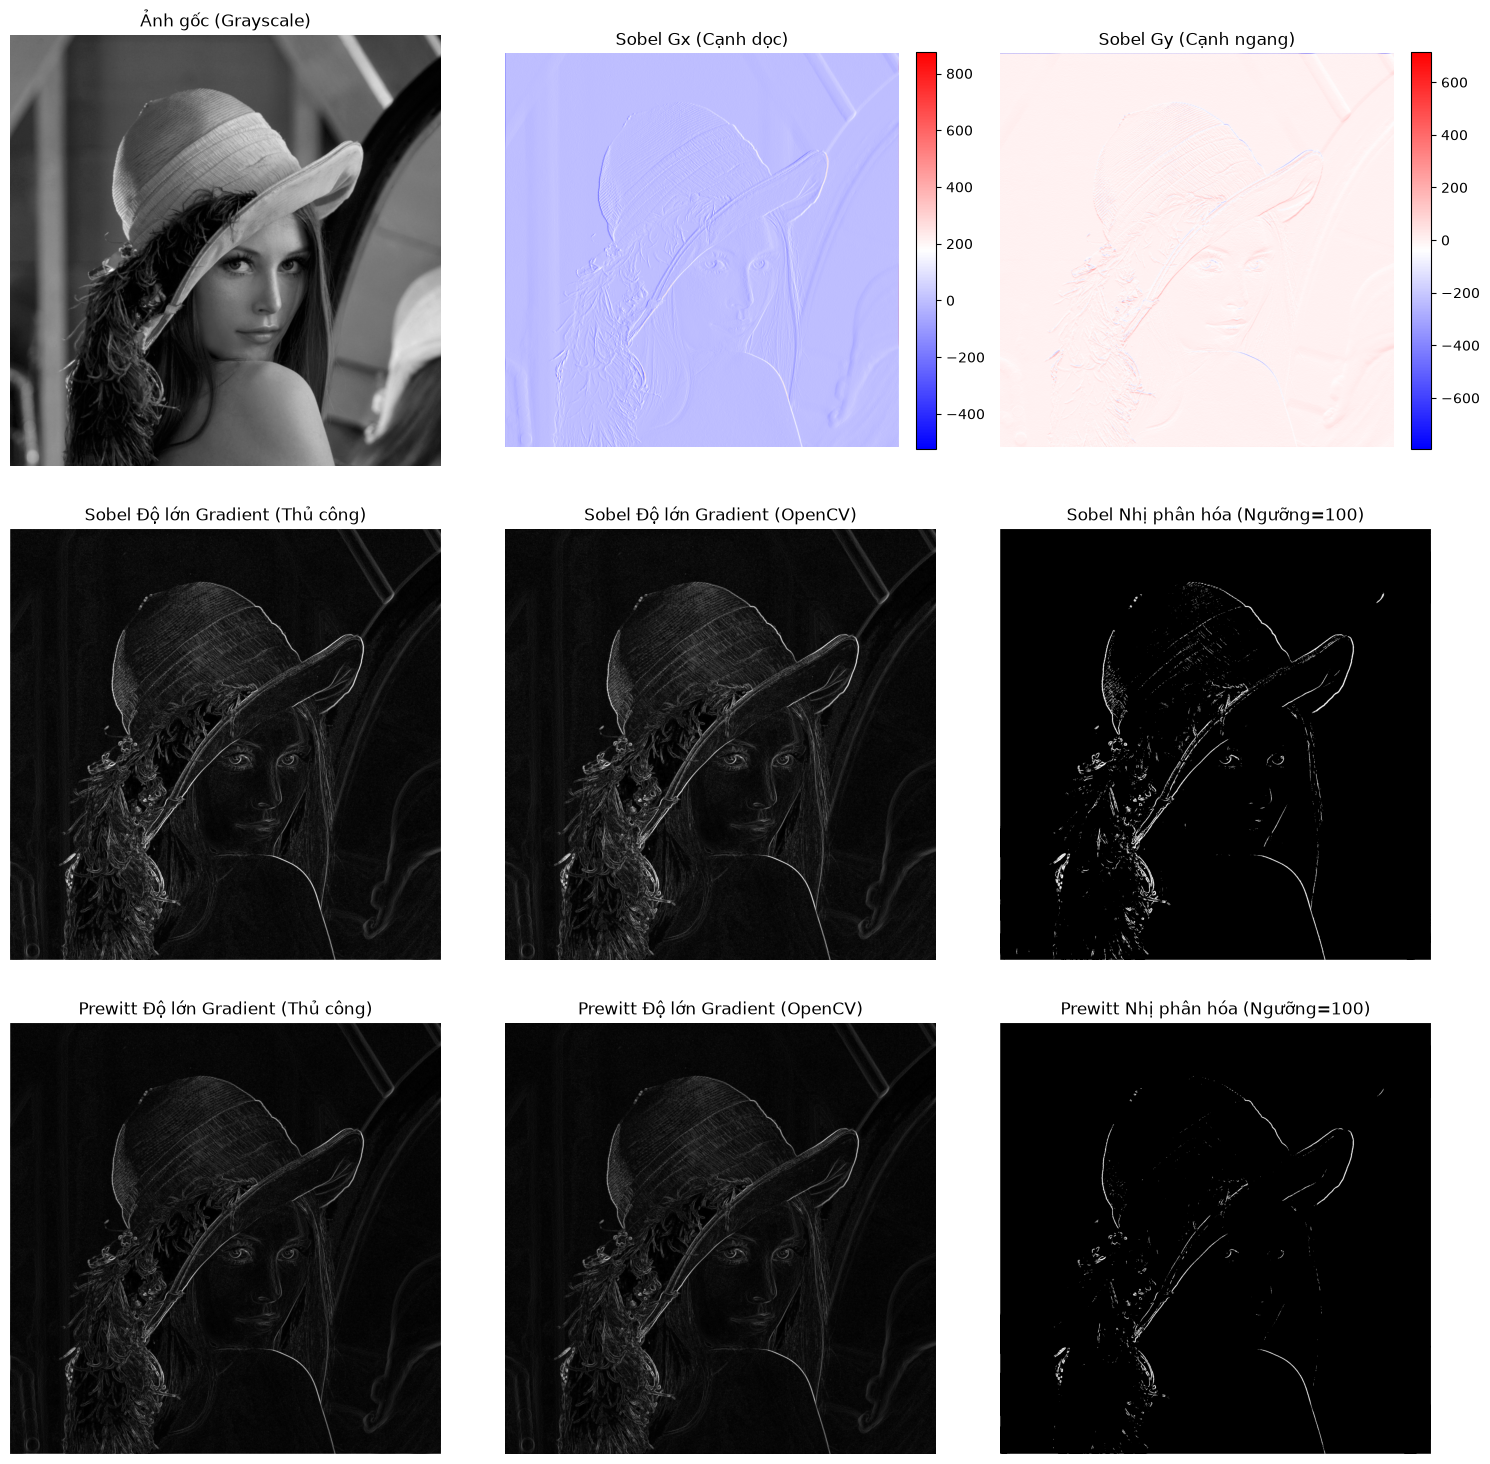

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title("Ảnh gốc (Grayscale)")
axes[0, 0].axis('off')

im_gx = axes[0, 1].imshow(sobel_Gx_m, cmap='bwr')
axes[0, 1].set_title("Sobel Gx (Cạnh dọc)")
axes[0, 1].axis('off')
fig.colorbar(im_gx, ax=axes[0, 1], fraction=0.046, pad=0.04)

im_gy = axes[0, 2].imshow(sobel_Gy_m, cmap='bwr')
axes[0, 2].set_title("Sobel Gy (Cạnh ngang)")
axes[0, 2].axis('off')
fig.colorbar(im_gy, ax=axes[0, 2], fraction=0.046, pad=0.04)

axes[1, 0].imshow(sobel_manual, cmap='gray')
axes[1, 0].set_title("Sobel Độ lớn Gradient (Thủ công)")
axes[1, 0].axis('off')

axes[1, 1].imshow(sobel_opencv, cmap='gray')
axes[1, 1].set_title("Sobel Độ lớn Gradient (OpenCV)")
axes[1, 1].axis('off')

axes[1, 2].imshow(sobel_thresh, cmap='gray')
axes[1, 2].set_title(f"Sobel Nhị phân hóa (Ngưỡng={thresh})")
axes[1, 2].axis('off')

axes[2, 0].imshow(prewitt_manual, cmap='gray')
axes[2, 0].set_title("Prewitt Độ lớn Gradient (Thủ công)")
axes[2, 0].axis('off')

axes[2, 1].imshow(prewitt_opencv, cmap='gray')
axes[2, 1].set_title("Prewitt Độ lớn Gradient (OpenCV)")
axes[2, 1].axis('off')

axes[2, 2].imshow(prewitt_thresh, cmap='gray')
axes[2, 2].set_title(f"Prewitt Nhị phân hóa (Ngưỡng={thresh})")
axes[2, 2].axis('off')

plt.tight_layout()
plt.savefig("sobel_prewitt_result.png", dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét:**

- Kết quả tính thủ công (`convolve2d_manual`) và dùng thư viện OpenCV (`cv2.filter2D`) cho ra ảnh gradient gần như giống hệt nhau ở cả Sobel và Prewitt, chứng tỏ hàm tích chập tự viết đã cài đặt đúng thuật toán.
- Sobel Gx bắt rõ các cạnh dọc/xiên như vành nón và các sợi tóc, trong khi Sobel Gy phản ứng yếu hơn nhiều vì ảnh gốc chứa ít cạnh ngang rõ nét.
- So sánh Sobel và Prewitt: hai kết quả khá tương đồng, nhưng Sobel cho đường biên sắc nét và ít nhiễu hơn một chút ở các chi tiết nhỏ (vùng tóc), do trọng số tâm của kernel Sobel lớn hơn (hệ số 2) giúp làm mượt nhiễu tốt hơn Prewitt.
- Sau khi ngưỡng hóa (threshold=100), các đường viền chính của khuôn mặt và vành nón được giữ lại rõ ràng, tuy nhiên vùng tóc xoăn vẫn còn khá nhiều nhiễu dạng đốm nhỏ — có thể cải thiện bằng cách tăng ngưỡng hoặc áp dụng lọc làm mượt (Gaussian blur) trước khi phát hiện cạnh.